# Round 5 — Fifty Products

Fifty products in ten groups of five. **Position limit 10 per product** — an order of magnitude
tighter than earlier rounds, which rules out concentrating risk anywhere.

**Scored 31,859.**

With fifty products the question is not what each one is but **which of the many apparent
relationships are real**. This notebook runs the same battery across all fifty, then prices
what survives.

Summary: [`rounds/05/README.md`](../rounds/05/README.md).
Specification: [`rounds/05/answer.md`](../rounds/05/answer.md).

In [1]:
import sys, warnings
sys.path.insert(0, "../tools")
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import figures as F
import product_props as pp
import prosperity_review as pr
from benchmarks import split_flow_by_aggressor

F.style()
DATA, RND, DAYS = "../data/round5", 5, [2, 3, 4]
GROUPS = ["GALAXY_SOUNDS", "MICROCHIP", "OXYGEN_SHAKE", "PANEL", "PEBBLES",
          "ROBOT", "SLEEP_POD", "SNACKPACK", "TRANSLATOR", "UV_VISOR"]

px = {d: pp.load(DATA, RND, d)[0] for d in DAYS}
tr = {d: pp.load(DATA, RND, d)[1] for d in DAYS}
PRODUCTS = sorted(px[2]["product"].unique())

def mid(f, p):
    g = f[f["product"] == p].set_index("timestamp")
    return ((g["bid_price_1"] + g["ask_price_1"]) / 2).ffill().bfill()

print(len(PRODUCTS), "products in", len(GROUPS), "groups")

50 products in 10 groups


## 1. Group structure — does any group sum to a constant?

Ten groups of five. If a group is a decomposition of one underlying quantity, its members'
prices should sum to something fixed.

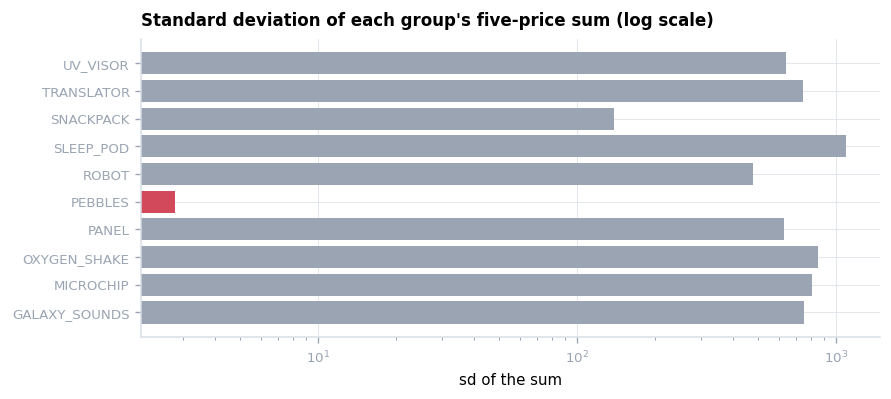

mean                        sd                  
day                  2        3        4       2        3        4
group                                                             
GALAXY_SOUNDS  51968.0  54715.0  55288.0  984.28   777.10   495.99
MICROCHIP      50039.0  50548.0  47637.0  778.15   807.36   823.12
OXYGEN_SHAKE   50076.0  50432.0  51271.0  407.13   672.69  1465.84
PANEL          49815.0  48836.0  48473.0  754.16   506.03   617.54
PEBBLES        50000.0  50000.0  50000.0    2.82     2.76     2.82
ROBOT          49387.0  49138.0  47904.0  553.52   504.35   369.20
SLEEP_POD      51969.0  54963.0  58378.0  958.17  1539.55   773.68
SNACKPACK      50041.0  50326.0  50296.0  161.05   131.38   124.51
TRANSLATOR     49258.0  49776.0  49688.0  594.41   530.23  1101.42
UV_VISOR       51021.0  51639.0  51753.0  573.20   425.29   913.16

In [2]:
rows = []
for g in GROUPS:
    members = [p for p in PRODUCTS if p.startswith(g)]
    for d in DAYS:
        s = sum(mid(px[d], m) for m in members)
        rows.append({"group": g, "day": d, "n": len(members),
                     "mean": round(s.mean()), "sd": round(s.std(), 2)})
gs = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7.5, 3.4))
w = gs.pivot(index="group", columns="day", values="sd")
ax.barh(range(len(w)), w.mean(axis=1), color=[F.HI if i == "PEBBLES" else F.GREY for i in w.index])
ax.set_yticks(range(len(w))); ax.set_yticklabels(w.index, fontsize=8)
ax.set_xscale("log")
F.finish(ax, "Standard deviation of each group's five-price sum (log scale)",
         "sd of the sum", "")
F.save(fig, "r5_group_sums")
gs.pivot(index="group", columns="day", values=["mean", "sd"])

**One group out of ten.** `PEBBLES` sums to exactly 50,000 with a standard deviation of 2.8 on
every day. The other nine sums drift by hundreds within a day and by thousands between days —
their means are not even stable across the three days.

$$\sum_{j \in \text{PEBBLES}} P^j_t \equiv 50{,}000$$

Relative error $5.6 \times 10^{-5}$.

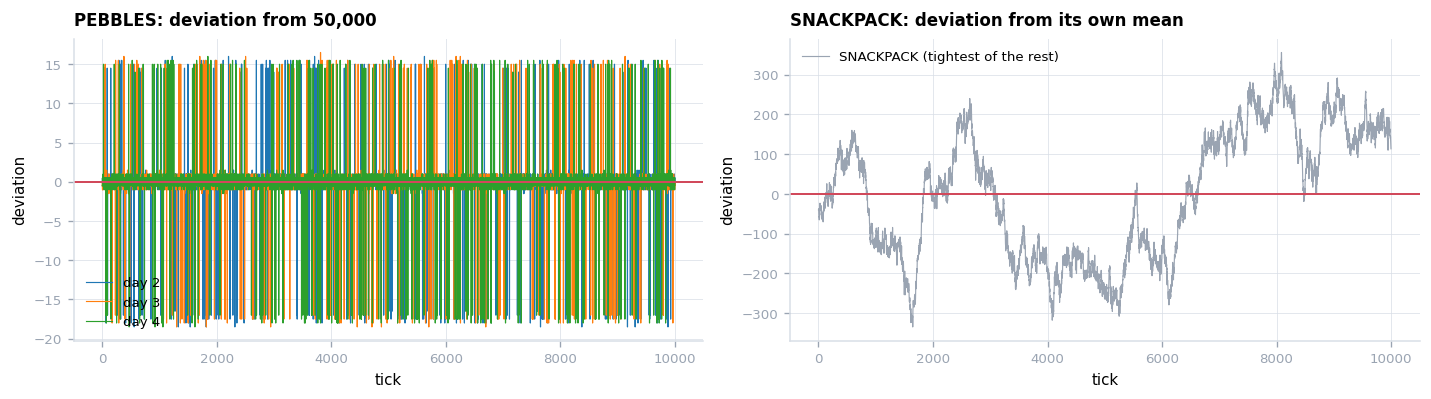

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
for d in DAYS:
    s = sum(mid(px[d], m) for m in [p for p in PRODUCTS if p.startswith("PEBBLES")])
    ax[0].plot(s.values - 50000, lw=.7, label=f"day {d}")
    if d == 2:
        s2 = sum(mid(px[d], m) for m in [p for p in PRODUCTS if p.startswith("SNACKPACK")])
        ax[1].plot(s2.values - s2.mean(), lw=.7, color=F.GREY, label="SNACKPACK (tightest of the rest)")
ax[0].axhline(0, color=F.HI, lw=1.2)
F.finish(ax[0], "PEBBLES: deviation from 50,000", "tick", "deviation", legend=True)
ax[1].axhline(0, color=F.HI, lw=1.2)
F.finish(ax[1], "SNACKPACK: deviation from its own mean", "tick", "deviation", legend=True)
F.save(fig, "r5_pebbles_identity")

Note the scales: PEBBLES holds within ±15 all session; the next-tightest group wanders by
hundreds around a mean that itself moves between days.

## 2. Can the identity be arbitraged?

The same question that Round 3's deep-ITM basis raised. An exact relationship is not
automatically a trade.

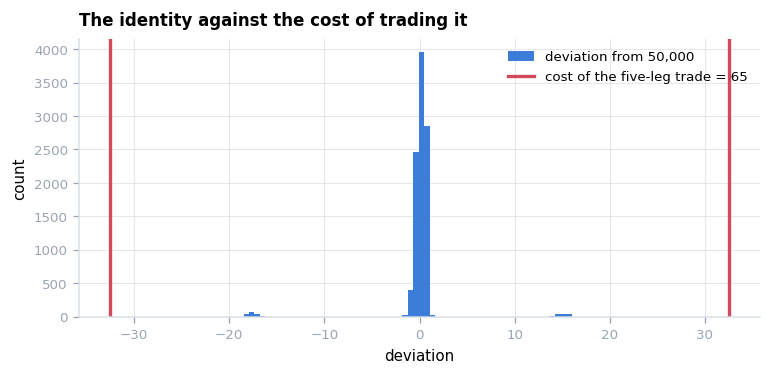

deviation sd 2.82   90th pct of |deviation| 1.00   five-leg cost 65


In [4]:
d = 2
members = [p for p in PRODUCTS if p.startswith("PEBBLES")]
s = sum(mid(px[d], m) for m in members)
cost = sum((px[d][px[d]["product"] == m]["ask_price_1"]
            - px[d][px[d]["product"] == m]["bid_price_1"]).median() for m in members)
dev = (s - 50000).abs()

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.hist((s - 50000).values, bins=60, color=F.BLUE, label="deviation from 50,000")
ax.axvline(-cost/2, color=F.HI, lw=2); ax.axvline(cost/2, color=F.HI, lw=2,
           label=f"cost of the five-leg trade = {cost:.0f}")
F.finish(ax, "The identity against the cost of trading it", "deviation", "count", legend=True)
F.save(fig, "r5_pebbles_cost")
print(f"deviation sd {s.std():.2f}   90th pct of |deviation| {np.percentile(dev, 90):.2f}"
      f"   five-leg cost {cost:.0f}")

**The entire distribution fits inside the cost of executing it.** Deviation sd 2.8 against 65
to trade all five legs — a factor of twenty.

**Its use is as a fair-value estimator**: knowing four members pins the fifth to ±3, tighter
than any single-product midpoint. Exactly the same conclusion as Round 3's option basis, for
exactly the same reason.

## 3. The five pairs that were traded

The submission traded five fitted pairs, $s_t = \log P^A_t - \beta \log P^B_t$. A fitted
$\beta$ makes any two series look related in sample; what matters is whether the resulting
spread reverts.

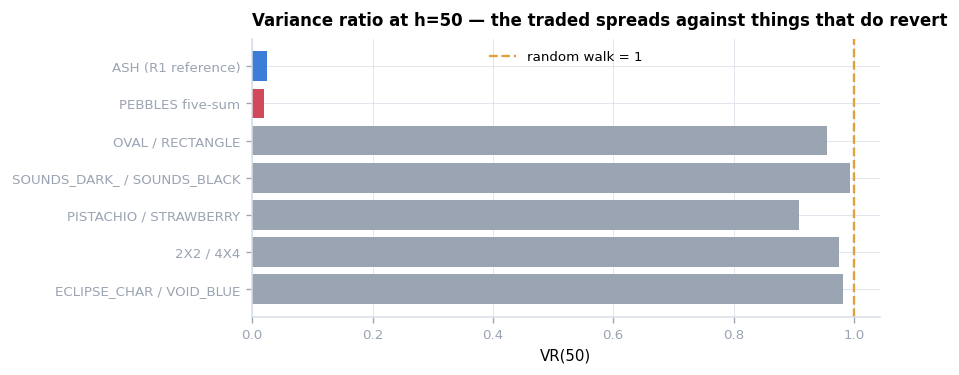

,pair,VR(50),VR(200)
0,ECLIPSE_CHAR / VOID_BLUE,0.982,0.943
1,2X2 / 4X4,0.975,0.848
2,PISTACHIO / STRAWBERRY,0.908,0.855
3,SOUNDS_DARK_ / SOUNDS_BLACK,0.993,0.940
4,OVAL / RECTANGLE,0.955,0.847


In [5]:
PAIRS = [("TRANSLATOR_ECLIPSE_CHARCOAL", "TRANSLATOR_VOID_BLUE", 0.500071),
         ("PANEL_2X2", "PANEL_4X4", -0.778745),
         ("SNACKPACK_PISTACHIO", "SNACKPACK_STRAWBERRY", -0.163593),
         ("GALAXY_SOUNDS_DARK_MATTER", "GALAXY_SOUNDS_BLACK_HOLES", 0.443447),
         ("MICROCHIP_OVAL", "MICROCHIP_RECTANGLE", 0.848069)]
rows = []
for A, B, beta in PAIRS:
    v50 = np.mean([pp.vr((np.log(mid(px[d], A)) - beta * np.log(mid(px[d], B))).values, 50)
                   for d in DAYS])
    v200 = np.mean([pp.vr((np.log(mid(px[d], A)) - beta * np.log(mid(px[d], B))).values, 200)
                    for d in DAYS])
    rows.append({"pair": f"{A.split('_',1)[1][:12]} / {B.split('_',1)[1][:12]}",
                 "VR(50)": round(v50, 3), "VR(200)": round(v200, 3)})
pairs = pd.DataFrame(rows)

peb = np.mean([pp.vr(sum(mid(px[d], m) for m in members).values, 50) for d in DAYS])
fig, ax = plt.subplots(figsize=(7.5, 3.2))
lab = list(pairs["pair"]) + ["PEBBLES five-sum", "ASH (R1 reference)"]
val = list(pairs["VR(50)"]) + [peb, 0.025]
ax.barh(range(len(lab)), val, color=[F.GREY]*5 + [F.HI, F.BLUE])
ax.axvline(1, color=F.ACCENT, ls="--", lw=1.4, label="random walk = 1")
ax.set_yticks(range(len(lab))); ax.set_yticklabels(lab, fontsize=8)
F.finish(ax, "Variance ratio at h=50 — the traded spreads against things that do revert",
         "VR(50)", "", legend=True)
F.save(fig, "r5_pairs_vr")
pairs

**All five sit between 0.91 and 0.99 — random walks.** The PEBBLES sum, on the same axis, is
0.020, and Round 1's ASH is 0.025.

**A factor of fifty.** The one quantity in this round that reverts was left alone; five that do
not were traded on the assumption that they would.

## 4. Sweeping all fifty for short-horizon reversion

Rounds 1–4 established the battery. Here it runs across every product, not just the ones
already suspected — a lag-1 autocorrelation of returns, per day.

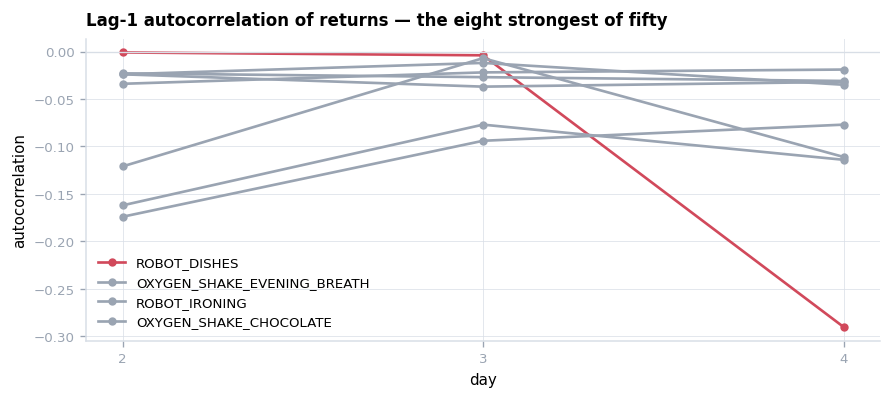

day,2,3,4,worst
product,,,,
ROBOT_DISHES,-0.001,-0.004,-0.290,0.290
OXYGEN_SHAKE_EVENING_BREATH,-0.174,-0.094,-0.077,0.174
ROBOT_IRONING,-0.162,-0.077,-0.114,0.162
OXYGEN_SHAKE_CHOCOLATE,-0.121,-0.007,-0.111,0.121
SNACKPACK_CHOCOLATE,-0.024,-0.037,-0.032,0.037
MICROCHIP_SQUARE,-0.024,-0.012,-0.035,0.035
SNACKPACK_PISTACHIO,-0.034,-0.022,-0.019,0.034
SNACKPACK_VANILLA,-0.023,-0.027,-0.031,0.031


In [6]:
rows = []
for d in DAYS:
    for prod in PRODUCTS:
        r = np.diff(mid(px[d], prod).values)
        if r.std() < 1e-9: continue
        rows.append({"product": prod, "day": d, "ac1": round(np.corrcoef(r[:-1], r[1:])[0, 1], 3)})
ac = pd.DataFrame(rows).pivot(index="product", columns="day", values="ac1")
ac["worst"] = ac.abs().max(1)
top = ac.sort_values("worst", ascending=False).head(8)

fig, ax = plt.subplots(figsize=(7.5, 3.4))
for i, (nm, row) in enumerate(top.iterrows()):
    ax.plot([2, 3, 4], row[[2, 3, 4]].values, "o-", lw=1.6, ms=4,
            color=F.HI if nm == "ROBOT_DISHES" else F.GREY,
            label=nm if i < 4 else None)
ax.axhline(0, color=F.GRID, lw=.8)
ax.set_xticks([2, 3, 4])
F.finish(ax, "Lag-1 autocorrelation of returns — the eight strongest of fifty", "day",
         "autocorrelation", legend=True)
F.save(fig, "r5_autocorr")
top

Four products stand out; the remaining forty-six never exceed 0.024 on any day.

**`ROBOT_DISHES` is the extreme case and the least consistent:** −0.001, −0.004, then −0.290.
Three others — `OXYGEN_SHAKE_EVENING_BREATH`, `ROBOT_IRONING`, `OXYGEN_SHAKE_CHOCOLATE` — are
weaker but **negative on all three days**.

By the standard Round 4 arrived at — consistency across days, not a single striking number —
the three quiet ones are better evidence than the loud one.

## 5. Are any of them tradeable?

An autocorrelation is not an edge until it clears the cost of acting on it. The predicted move
is $|\rho| \times \mathbb{E}|r|$; crossing the spread costs half of it.

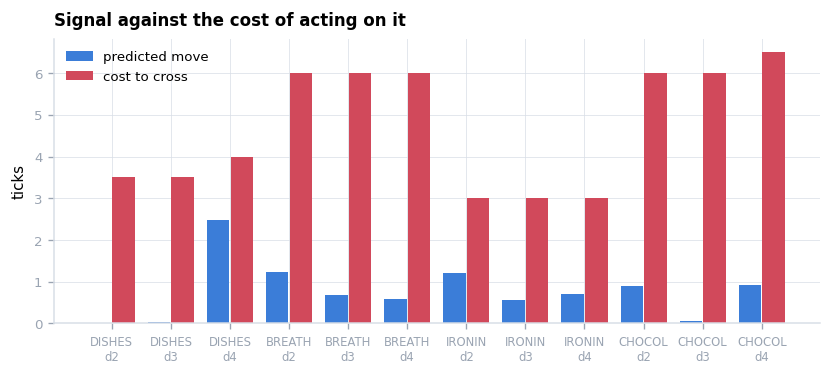

,product,day,ac1,predicted move,half-spread,crossable
0,ROBOT_DISHES,2,-0.001,0.01,3.5,False
1,ROBOT_DISHES,3,-0.004,0.03,3.5,False
2,ROBOT_DISHES,4,-0.290,2.48,4.0,False
3,OXYGEN_SHAKE_EVENING_BREATH,2,-0.174,1.23,6.0,False
4,OXYGEN_SHAKE_EVENING_BREATH,3,-0.094,0.69,6.0,False
5,OXYGEN_SHAKE_EVENING_BREATH,4,-0.077,0.59,6.0,False
6,ROBOT_IRONING,2,-0.162,1.21,3.0,False
7,ROBOT_IRONING,3,-0.077,0.55,3.0,False
8,ROBOT_IRONING,4,-0.114,0.71,3.0,False
9,OXYGEN_SHAKE_CHOCOLATE,2,-0.121,0.90,6.0,False


In [7]:
cand = ["ROBOT_DISHES", "OXYGEN_SHAKE_EVENING_BREATH", "ROBOT_IRONING", "OXYGEN_SHAKE_CHOCOLATE"]
rows = []
for prod in cand:
    for d in DAYS:
        g = px[d][px[d]["product"] == prod].set_index("timestamp")
        m = mid(px[d], prod).values
        r = np.diff(m); rho = np.corrcoef(r[:-1], r[1:])[0, 1]
        sp = (g["ask_price_1"] - g["bid_price_1"]).median()
        rows.append({"product": prod, "day": d, "ac1": round(rho, 3),
                     "predicted move": round(abs(rho) * np.abs(r).mean(), 2),
                     "half-spread": sp / 2,
                     "crossable": abs(rho) * np.abs(r).mean() > sp / 2})
trd = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 3.2))
x = np.arange(len(trd))
ax.bar(x - .2, trd["predicted move"], .38, color=F.BLUE, label="predicted move")
ax.bar(x + .2, trd["half-spread"], .38, color=F.HI, label="cost to cross")
ax.set_xticks(x); ax.set_xticklabels([f"{p.split('_')[-1][:6]}\nd{d}"
                                      for p, d in zip(trd["product"], trd["day"])], fontsize=7)
F.finish(ax, "Signal against the cost of acting on it", "", "ticks", legend=True)
F.save(fig, "r5_tradeable")
trd

**Not one clears the spread — including `ROBOT_DISHES` on its strongest day** (2.48 predicted
against a 4.0 half-spread).

That rules out crossing. It does not rule out **quoting**: a resting order does not pay the
spread, it earns it. The autocorrelation then enters as a shift of the quoting centre rather
than as a reason to trade.

So the right question is how much flow those products offer.

In [8]:
rows = []
for prod in cand:
    for d in DAYS:
        f = split_flow_by_aggressor(px[d], tr[d], prod)
        g = px[d][px[d]["product"] == prod]
        sp = (g["ask_price_1"] - g["bid_price_1"]).median()
        fl = min(f["to_my_bid"].sum(), f["to_my_ask"].sum())
        rows.append({"product": prod, "day": d, "flow": int(fl), "spread": sp,
                     "MM ceiling/day": int(fl * max(sp - 2, 0) / 2)})
mm = pd.DataFrame(rows)
mm.pivot(index="product", columns="day", values="MM ceiling/day")

day,2,3,4
product,,,
OXYGEN_SHAKE_CHOCOLATE,1385,1600,1556
OXYGEN_SHAKE_EVENING_BREATH,1385,1600,1415
ROBOT_DISHES,692,800,849
ROBOT_IRONING,554,640,566


**A few hundred to about 1,600 a day each** — real, and orders of magnitude away from the
389,000 that a public write-up attributes to `ROBOT_DISHES` on its strong day.

That figure can be bounded independently. The position limit is 10 lots, and the product's
full daily range is about 1,300, so **perfect foresight with the position flipped at every
turning point caps out near 13,000**:

In [9]:
rows = []
for prod in ["ROBOT_DISHES", "OXYGEN_SHAKE_EVENING_BREATH"]:
    for d in DAYS:
        m = mid(px[d], prod)
        rows.append({"product": prod, "day": d, "open->close": round(m.iloc[-1] - m.iloc[0]),
                     "low->high": round(m.max() - m.min()),
                     "10 lots x full range": f"{10 * (m.max() - m.min()):,.0f}"})
pd.DataFrame(rows)

,product,day,open->close,low->high,10 lots x full range
0,ROBOT_DISHES,2,-79,1322,"13,225"
1,ROBOT_DISHES,3,218,1023,"10,230"
2,ROBOT_DISHES,4,1077,1302,"13,020"
3,OXYGEN_SHAKE_EVENING_BREATH,2,-1570,2022,"20,225"
4,OXYGEN_SHAKE_EVENING_BREATH,3,1000,1280,"12,800"
5,OXYGEN_SHAKE_EVENING_BREATH,4,-10,1143,"11,430"


**A single product cannot produce 389,000 under a 10-lot limit.** Capturing the entire daily
range with the position always maximally right is worth about 13,000.

The figure is not reproducible from this data, and the mechanism it would require does not
exist here. **Recorded, not adopted.**

What *is* supported: a persistent negative autocorrelation on four products, worth a few
hundred to 1,600 a day each as a lean on the quoting centre.

## 6. Where the flow is across all fifty

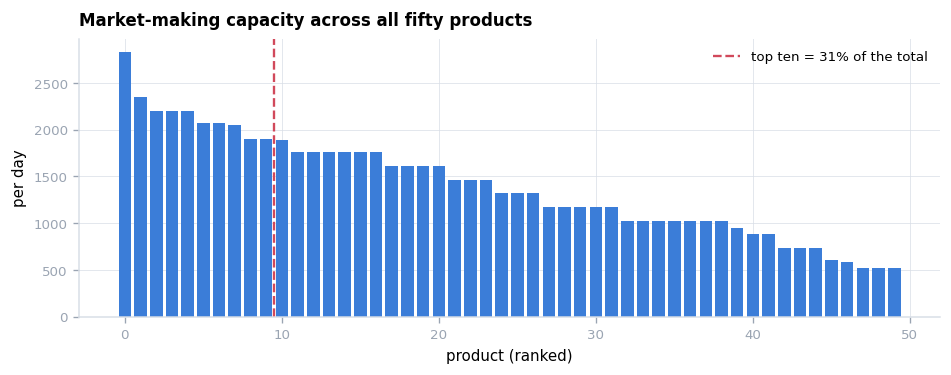

all fifty: 69,761/day


,product,flow/day,spread,MM ceiling/day
23,PEBBLES_XL,377,17.0,2832
38,SNACKPACK_STRAWBERRY,293,18.0,2346
39,SNACKPACK_VANILLA,293,17.0,2200
37,SNACKPACK_RASPBERRY,293,17.0,2200
35,SNACKPACK_CHOCOLATE,293,17.0,2200
20,PEBBLES_L,377,13.0,2077
21,PEBBLES_M,377,13.0,2077
36,SNACKPACK_PISTACHIO,293,16.0,2053
46,UV_VISOR_MAGENTA,293,15.0,1906
12,OXYGEN_SHAKE_GARLIC,293,15.0,1906


In [10]:
rows = []
for prod in PRODUCTS:
    tb = ta = 0.0; sp = []
    for d in DAYS:
        f = split_flow_by_aggressor(px[d], tr[d], prod)
        tb += f["to_my_bid"].sum(); ta += f["to_my_ask"].sum()
        g = px[d][px[d]["product"] == prod]
        sp.append((g["ask_price_1"] - g["bid_price_1"]).median())
    s = float(np.nanmedian(sp)); n = len(DAYS)
    rows.append({"product": prod, "flow/day": int(min(tb, ta) / n), "spread": s,
                 "MM ceiling/day": int(min(tb, ta) / n * max(s - 2, 0) / 2)})
flow = pd.DataFrame(rows).sort_values("MM ceiling/day", ascending=False)

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(range(len(flow)), flow["MM ceiling/day"], color=F.BLUE)
ax.axvline(9.5, color=F.HI, ls="--", lw=1.4,
           label=f"top ten = {100*flow.head(10)['MM ceiling/day'].sum()/flow['MM ceiling/day'].sum():.0f}% of the total")
F.finish(ax, "Market-making capacity across all fifty products", "product (ranked)",
         "per day", legend=True)
F.save(fig, "r5_flow_all")
print(f"all fifty: {flow['MM ceiling/day'].sum():,}/day")
flow.head(10)

**About 70,000 a day in aggregate, and the top ten are only a third of it.**

Two consequences. **Breadth beats depth** — no product can carry the round, and with a 10-lot
limit none is permitted to. And the available market-making revenue is **more than double the
realised score of 31,859**.

## 7. What the submission did

Three modules: five fitted pairs, six hard-coded directional bets, four market-made products.
Splitting the realised PnL by how many fills each product saw separates the bets from the
trading.

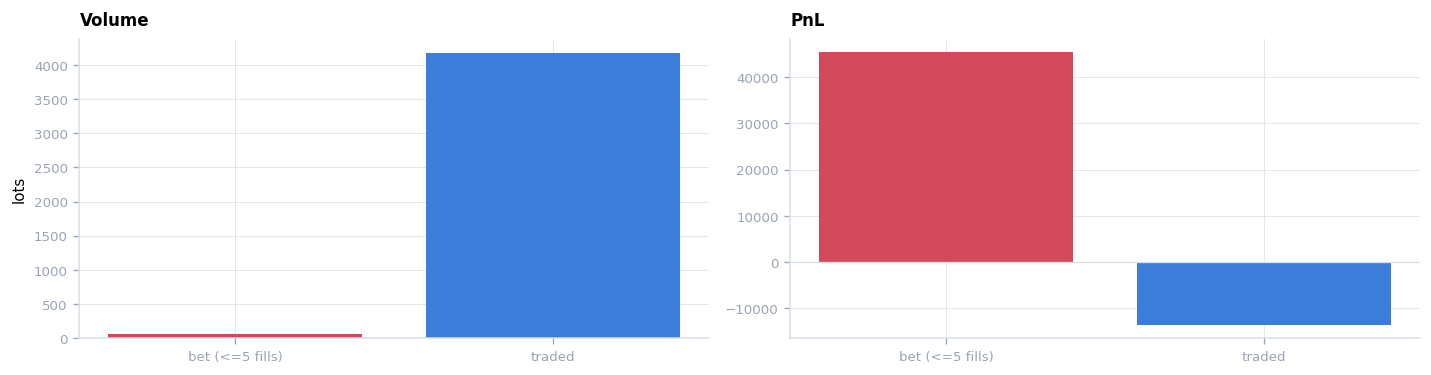

,products,lots,PnL
kind,,,
bet (<=5 fills),6,60,45376.0
traded,14,4175,-13518.0


In [11]:
log = pr.load_log("../submissions/round5.log")
a, t = log.activities, log.trades
rows = []
for P in sorted(a["product"].unique()):
    o = t[(t["symbol"] == P) & (t["side"] != 0)]
    if len(o) == 0: continue
    rows.append({"product": P, "PnL": a[a["product"] == P]["profit_and_loss"].iloc[-1],
                 "fills": len(o), "lots": int(o["quantity"].sum()),
                 "kind": "bet (<=5 fills)" if len(o) <= 5 else "traded"})
d5 = pd.DataFrame(rows)
summary = d5.groupby("kind").agg(products=("product", "size"), lots=("lots", "sum"),
                                 PnL=("PnL", "sum")).round(0)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
ax[0].bar(summary.index, summary["lots"], color=[F.HI, F.BLUE])
F.finish(ax[0], "Volume", "", "lots")
ax[1].bar(summary.index, summary["PnL"], color=[F.HI, F.BLUE])
ax[1].axhline(0, color=F.GRID, lw=.8)
F.finish(ax[1], "PnL", "", "")
F.save(fig, "r5_decomposition")
summary

**Sixty lots produced +45,376. Four thousand lots produced −13,518.**

The entire score, and more, came from six positions opened at $t=0$ and held to the close —
four right, two wrong. With a 10-lot limit and daily ranges above 2,000, one correct bet is
worth about 25,000, so the result was set by which way four coins landed.

### Did the six directions have any basis?

In [12]:
TREND = {"PEBBLES_XL": 1, "OXYGEN_SHAKE_GARLIC": 1, "TRANSLATOR_SPACE_GRAY": -1,
         "MICROCHIP_TRIANGLE": -1, "GALAXY_SOUNDS_SOLAR_FLAMES": 1,
         "GALAXY_SOUNDS_PLANETARY_RINGS": 1}
rows = []
for prod, dirn in TREND.items():
    moves = [mid(px[d], prod).iloc[-1] - mid(px[d], prod).iloc[0] for d in DAYS]
    rows.append({"product": prod, "bet": dirn,
                 **{f"d{d}": round(m) for d, m in zip(DAYS, moves)},
                 "agree": sum(np.sign(m) == dirn for m in moves)})
pd.DataFrame(rows)

,product,bet,d2,d3,d4,agree
0,PEBBLES_XL,1,3674,-1552,4014,2
1,OXYGEN_SHAKE_GARLIC,1,1828,111,1958,3
2,TRANSLATOR_SPACE_GRAY,-1,-507,638,-1690,2
3,MICROCHIP_TRIANGLE,-1,704,-1706,-1078,2
4,GALAXY_SOUNDS_SOLAR_FLAMES,1,1346,-694,180,2
5,GALAXY_SOUNDS_PLANETARY_RINGS,1,1249,158,-1767,2


**Five of six agree on two days out of three** — the modal outcome of three coin flips, which
occurs about 38% of the time per product under no signal at all.

The realised result, four right and two wrong, is exactly what that predicts.